In [1]:
import sys 
import os 
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
sys.path.append('../')


In [2]:
from src.utils.normalizer import Normalizer

In [14]:
# linear_layer = "layer_1/mlp.up_proj"
with torch.no_grad():
    linear_layer = "layer_0/self_attn.k_proj"
    model = "Llama-2-7b"
    weight = f"/data/lliu/huffman/models/meta-llama/{model}-hf/original_weights/{linear_layer}.pt"
    hessianDiag = f"/data/lliu/huffman/models/meta-llama/{model}-hf/hessianDiags/seed_0/pajama/128/{linear_layer}.pt"

    weight = torch.load(weight, map_location='cpu')["weight"].detach().to(torch.float32)
    _,weight_normalized = Normalizer.normalize_init(weight, [0,1], [False,False],norm_rescale=True, powers=1,
                                                    p=2)
    hessianDiag = torch.load(hessianDiag, map_location='cpu')["hessianDiag"].detach().to(torch.float32)
    


    d_out, d_in = weight.shape

In [15]:
#for the plot downsample X to the chosen number of points
downsample_factor = 4

downsampler = torch.nn.MaxPool1d(downsample_factor, stride=downsample_factor)

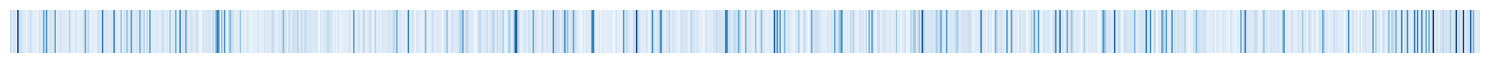

In [16]:
#plot out the norms
plt.figure(figsize = (15,1),layout = "tight")
plt.imshow(torch.log(downsampler(hessianDiag.unsqueeze(0).unsqueeze(0))).detach().cpu().numpy().reshape(1,-1),
           aspect = 30, cmap = "Blues")
plt.axis("off")
plt.savefig("../plots/test_diag.png", bbox_inches='tight', pad_inches=0)

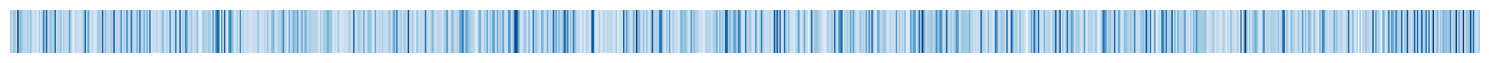

In [17]:
#plot out the norms
plt.figure(figsize = (15,1),layout = "tight")
plt.imshow(torch.log(downsampler(_.norms[0].data.unsqueeze(0).unsqueeze(0))).detach().cpu().numpy().reshape(1,-1),
           aspect = 30, cmap = "Blues")
plt.axis("off")
plt.savefig("../plots/test.png", bbox_inches='tight', pad_inches=0)

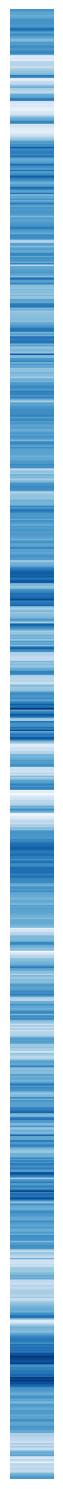

In [19]:
#plot out the norms
plt.figure(figsize = (1,15),layout = "tight")
plt.imshow(torch.log(downsampler(_.norms[1].data.unsqueeze(0).unsqueeze(0))).detach().cpu().numpy().reshape(-1,1),
           aspect = 1/30, cmap = "Blues")
plt.axis("off")
plt.savefig("../plots/test2.png", bbox_inches='tight', pad_inches=0)

In [20]:
type(_.norms[0].data.clone().detach().cpu().numpy().reshape(1,-1))

numpy.ndarray

In [21]:
_.norms[0].data.detach().cpu().numpy().reshape(1,-1)

array([[1.1756535 , 0.8264306 , 0.30965513, ..., 0.58908206, 0.65510875,
        0.5813739 ]], shape=(1, 4096), dtype=float32)

In [22]:
_.norms[0].data.detach().cpu().numpy().reshape(1,-1)

array([[1.1756535 , 0.8264306 , 0.30965513, ..., 0.58908206, 0.65510875,
        0.5813739 ]], shape=(1, 4096), dtype=float32)

In [23]:
X = torch.stack((torch.abs(weight),
             torch.abs(weight_normalized),
             torch.abs(weight*hessianDiag.unsqueeze(0).sqrt()),
             torch.abs(weight_normalized*hessianDiag.unsqueeze(0).sqrt())),
              )
print(X.shape)

torch.Size([4, 4096, 4096])


In [24]:
#for the plot downsample X to the chosen number of points
downsample_factor = 4
with torch.no_grad():
    downsampler = torch.nn.MaxPool2d(kernel_size = (downsample_factor,downsample_factor), stride = (downsample_factor, downsample_factor))
    X_downsampled = downsampler(X)
    
d_out_downsampled, d_in_downsampled = X_downsampled.shape[1:]

In [25]:
def clipping_fn(x,perc_clip = 99):
    return np.clip(x,
                   np.percentile(x,100-perc_clip)
                   ,np.percentile(x,perc_clip))

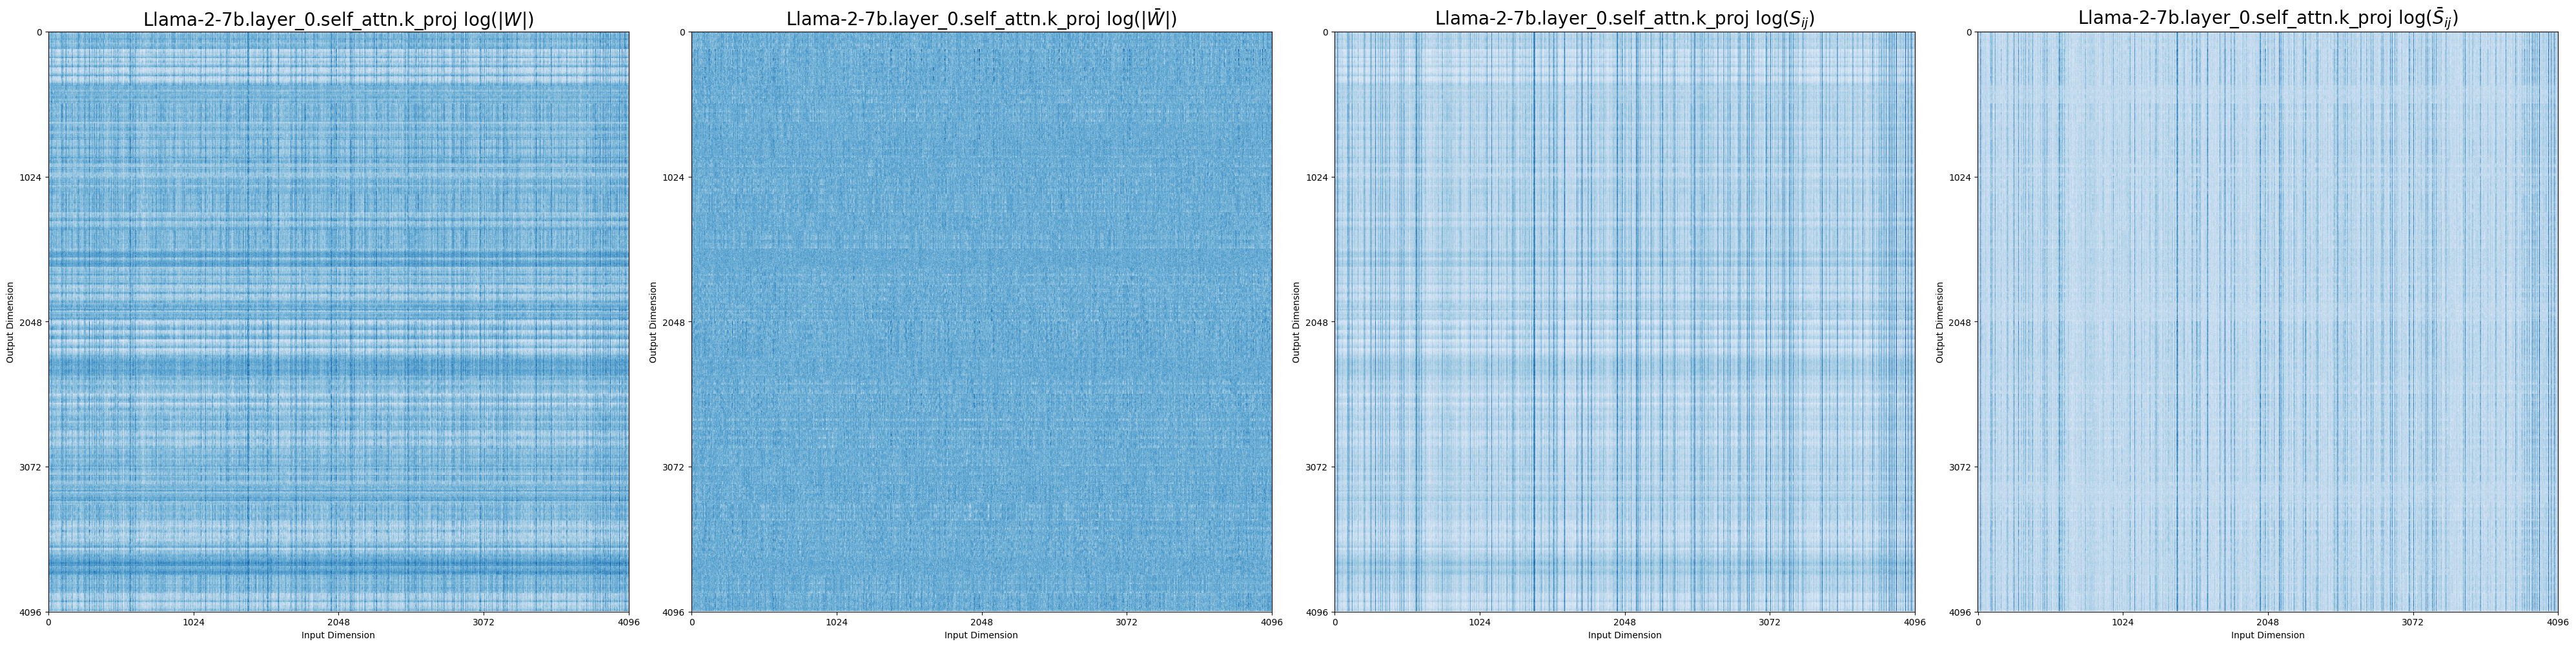

In [27]:
#plot the two weight matricies side by side

figsize = 7.5
fig, axs = plt.subplots(1,4, figsize=(40,10), layout='tight')

labels = ["$\\log(|W|)$", "$\\log(|\\bar{W}|)$", "$\\log(S_{ij})$", "$\\log(\\bar{S}_{ij})$"]
for i in range(len(labels)):
    axs[i].imshow(clipping_fn(torch.log(X_downsampled[i]).numpy(),100), aspect='equal', cmap='Blues')
    axs[i].set_title(f"{model}.{linear_layer.replace("/",".")} {labels[i]}", fontsize=20)
    axs[i].set_xlabel("Input Dimension")
    axs[i].set_ylabel("Output Dimension")
    
    #set the ticks to correspond to the original weight matrix
    axs[i].set_xticks(np.arange(0,d_in_downsampled+1,d_in_downsampled//4))
    axs[i].set_xticklabels(np.arange(0,d_in+1,d_in//4))
    axs[i].set_yticks(np.arange(0,d_out_downsampled+1,d_out_downsampled//4))
    axs[i].set_yticklabels(np.arange(0,d_out+1,d_out//4))

plt.savefig(f"../plots/importances.png")

In [192]:
#plot the two weight matricies side by side

fig, ax = plt.subplots(1,2, figsize=(10,5))

clip_percentile = 0.99

#max pool downsample both weights
weight = weight.reshape(d_out, d_in//4, 4).max(-1)[0]
weight_normalized = weight_normalized.reshape(d_out, d_in//4, 4).max(-1)[0]

weight = weight.reshape(d_out//4,

im = ax[0].imshow(np.clip(np.abs(weight), 0, np.percentile(np.abs(weight), clip_percentile*100)))
                  
ax[0].set_title("Original Weight")
fig.colorbar(im, ax=ax[0])

im = ax[1].imshow(np.clip(np.abs(weight_normalized), 0, np.percentile(np.abs(weight_normalized), clip_percentile*100)))
fig.colorbar(im, ax=ax[1])

SyntaxError: '(' was never closed (3646594971.py, line 11)

In [ ]:
#measure the mu incovariance
mu_w = torch.max(torch.abs(weight))*np.sqrt(np.prod(weight.shape))/torch.norm(weight)
mu_w_norm = torch.max(torch.abs(weight_normalized))*np.sqrt(np.prod(weight_normalized.shape))/torch.norm(weight_normalized)

print(f"mu_w: {mu_w}")
print(f"mu_w_norm: {mu_w_norm}")

mu_w: 54.11859893798828
mu_w_norm: 15.060064315795898


In [193]:
#try to use PCA to reduce the dimensionality
d= 6

#pad the weight and weight_normalized to make it divisible by d
d_in_pad = d_in + d - d_in%d
print(weight.shape)
weight = np.pad(weight, ((0,0),(0,d_in_pad-d_in)), mode='constant', constant_values=0)
print(weight.shape)
weight_normalized = np.pad(weight_normalized, ((0,0),(0,d_in_pad-d_in)), mode='constant', constant_values=0)

weight_d = weight.reshape(-1, d)
weight_normalized_d = weight_normalized.reshape(-1, d)

torch.Size([4096, 4096])
(4096, 4098)


In [194]:
import sklearn.decomposition

pca = sklearn.decomposition.PCA(n_components=d)

weight_2d = pca.fit_transform(weight_d)

weight_normalized_2d = pca.fit_transform(weight_normalized_d)

In [195]:
#get the weights as a 2d array 
# weight_2d = weight.reshape(-1,2)

# weight_normalized_2d = weight_normalized.reshape(-1,2)

# #get the two histograms

# H_w,x_w,y_w = np.histogram2d(weight_2d[:,0], weight_2d[:,1], bins=400,density=True)
# H_w = H_w.T

# H_norm,x_norm,y_norm = np.histogram2d(weight_normalized_2d[:,0], weight_normalized_2d[:,1], bins=400,density=True)
# H_norm = H_norm.T


In [196]:
clip_percentile = 0.9999
weight_range = np.percentile(weight_2d.flatten(), [(1-clip_percentile)*100, clip_percentile*100])
weight_normalized_range = np.percentile(weight_normalized_2d.flatten(), [(1-clip_percentile)*100, clip_percentile*100])

H_w,x_w,y_w = np.histogram2d(weight_2d[:,0], weight_2d[:,1], bins=900,density=True,
                                        range = [weight_range, weight_range])
H_w = H_w.T

H_norm,x_norm,y_norm = np.histogram2d(weight_normalized_2d[:,0], weight_normalized_2d[:,1], bins=900,density=True,
                                      range = [weight_normalized_range, weight_normalized_range])
H_norm = H_norm.T

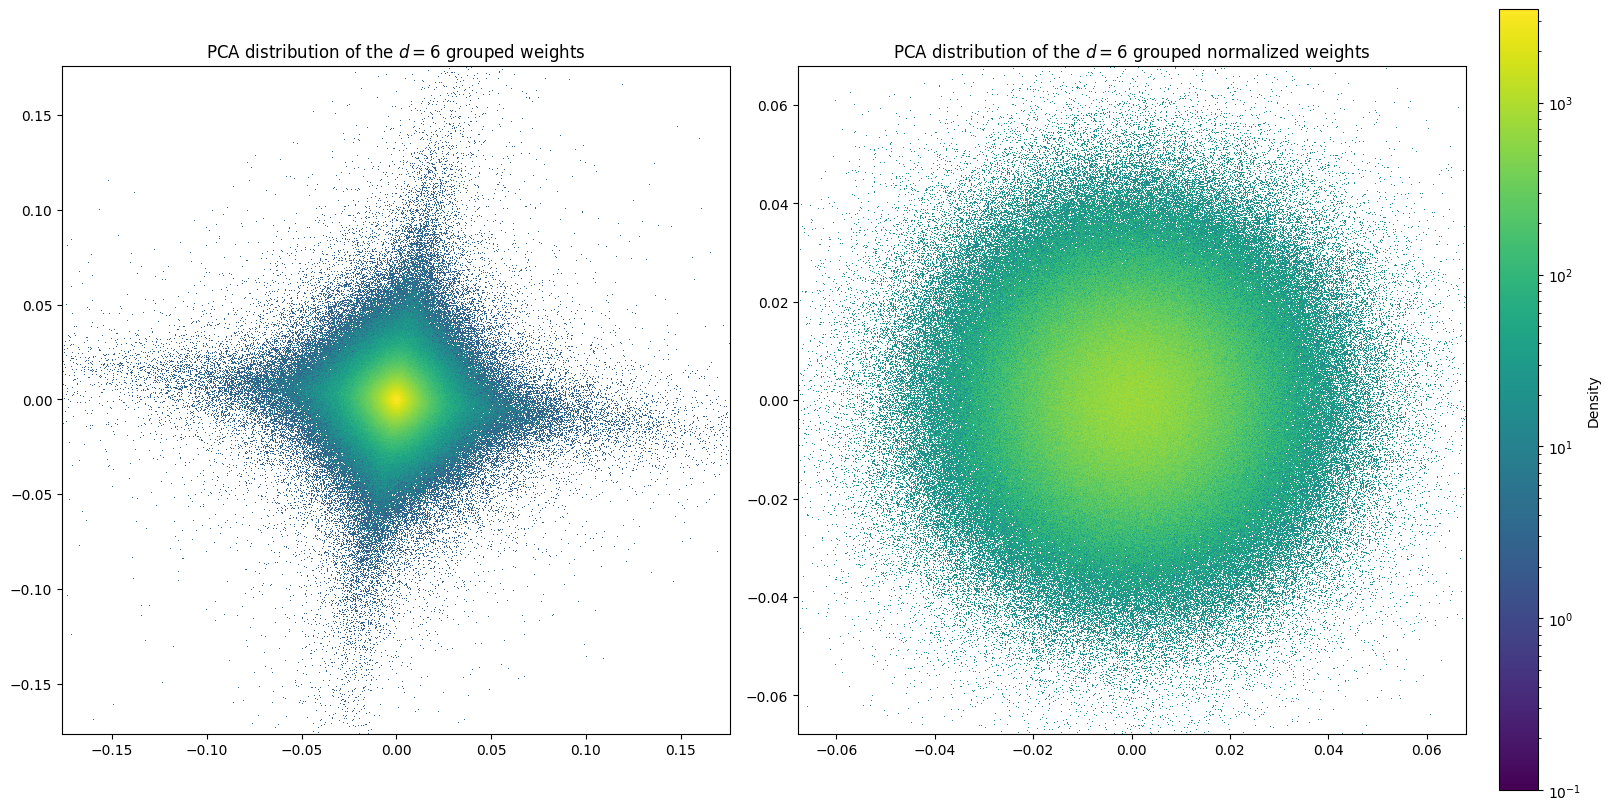

In [197]:
size = 8
fig,axs = plt.subplots(1,2, figsize=(size*2,size), constrained_layout=True
                        # sharex=True, sharey=True
                        )

norm = mcolors.LogNorm(vmin=max(min(H_w.min(), H_norm.min()),1e-1), vmax=max(H_w.max(), H_norm.max()), clip=False)
plt.sca(axs[0])
plt.title("PCA distribution of the $d=6$ grouped weights")
plt.imshow(H_w, extent=(x_w.min(), x_w.max(), y_w.min(), y_w.max()), origin='lower', interpolation='nearest',
           aspect="equal", norm=norm, cmap='viridis')
# plt.colorbar()

plt.sca(axs[1])
plt.title("PCA distribution of the $d=6$ grouped normalized weights")
plt.imshow(H_norm, extent=(x_norm.min(), x_norm.max(), y_norm.min(), y_norm.max()), origin='lower', interpolation='nearest',
           aspect="equal", norm=norm)

colorbar = plt.colorbar()
colorbar.set_label("Density")

plt.savefig("weight_distribution.png")

/tmp/ipykernel_1055820/3693937209.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(H_norm), extent=(x_norm.min(), x_norm.max(), y_norm.min(), y_norm.max()), origin='lower',cmap = "Greys")


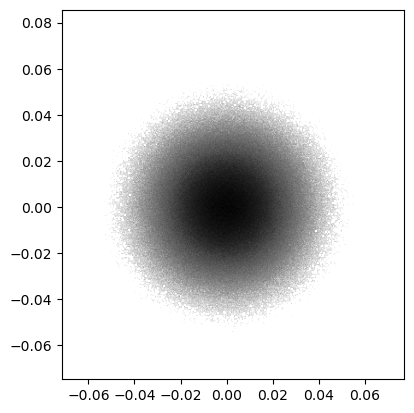

In [10]:
plt.imshow(np.log(H_norm), extent=(x_norm.min(), x_norm.max(), y_norm.min(), y_norm.max()), origin='lower',cmap = "Greys")